# A09 Appendix Boundary Conditions and Portability

LaTeX slot: `fig:appendix-boundary-conditions`

This notebook stays intentionally compact.

It only keeps two supporting questions:
1. Where does RouteRec become fragile as the target-data budget shrinks?
2. Which transfer-style reuse choices are least harmful, once we step away from full finetuning?

In [ ]:
from pathlib import Path
import sys
import importlib

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path('/workspace/FeaturedMoE/writing/260418_final_exp_figure')
DATA_DIR = ROOT / 'data'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import slot_viz_helpers as viz
importlib.reload(viz)

from slot_viz_helpers import line_panel, setup_style

setup_style()

low_resource_df = pd.read_csv(DATA_DIR / 'A09_low_resource_transfer.csv')
variant_df = pd.read_csv(DATA_DIR / 'A09_transfer_variants.csv')

datasets = ['Beauty', 'ML-1M']
variant_order = ['shared_ffn', 'dense_route_rec', 'sequence_only', 'group_top1']
variant_label_map = {
    'shared_ffn': 'Shared FFN',
    'dense_route_rec': 'Dense RouteRec',
    'sequence_only': 'Sequence only',
    'group_top1': 'Group top-1',
}
transfer_label_map = {
    'finetune_all': 'Finetune all weights',
    'freeze_router': 'Freeze router, finetune backbone',
    'group_router': 'Reuse only group-level routing',
    'anchor_init': 'Warm-start with anchor initialization',
}
shot_order = ['5%', '10%', '20%', '50%']

### (a) Low-data quality curves

Interpretation target: if dense RouteRec becomes fragile in low-data settings, sparse-like routing may serve as a more stable control path.


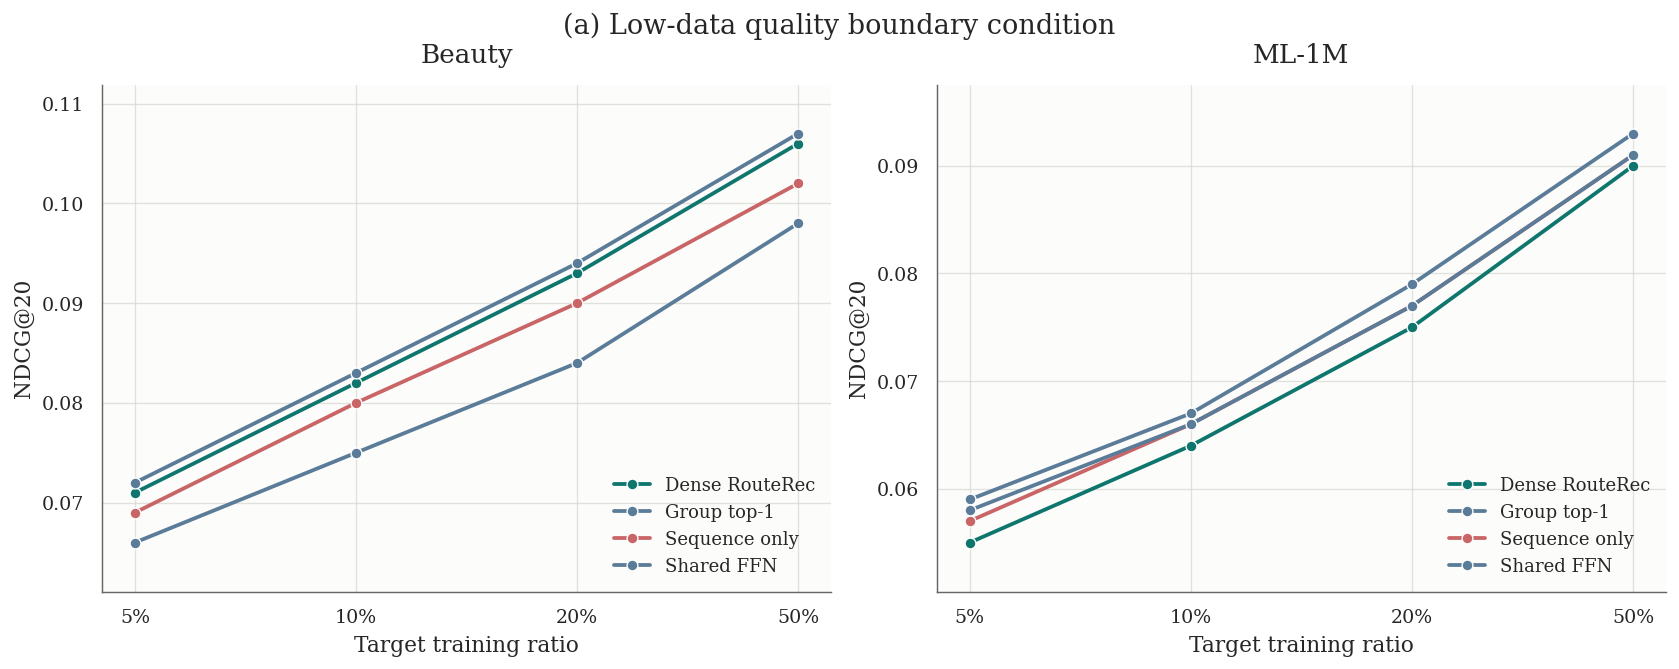

In [2]:
display(Markdown('### (a) Low-data quality boundary'))
print('Interpretation target: this panel is not a victory lap. It marks where dense RouteRec still holds up and where reduced data budgets become a real boundary condition.')
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8), constrained_layout=True)
for axis, dataset in zip(axes, datasets):
    subset = low_resource_df[low_resource_df['dataset'] == dataset].copy()
    subset['shot_ratio'] = pd.Categorical(subset['shot_ratio'], categories=shot_order, ordered=True)
    subset = subset.sort_values(['variant', 'shot_ratio'])
    line_panel(
        subset,
        x='shot_ratio',
        y='ndcg20',
        hue='variant',
        ax=axis,
        title=dataset,
        ylabel='NDCG@20',
        xlabel='Target training budget',
        hue_order=variant_order,
    )
    handles, labels = axis.get_legend_handles_labels()
    axis.legend(handles, [variant_label_map.get(label, label) for label in labels], loc='lower right', frameon=False)
fig.suptitle('(a) RouteRec under shrinking target-data budgets', y=1.04, fontsize=15)
plt.show()

### (c) Compact transfer-style support view

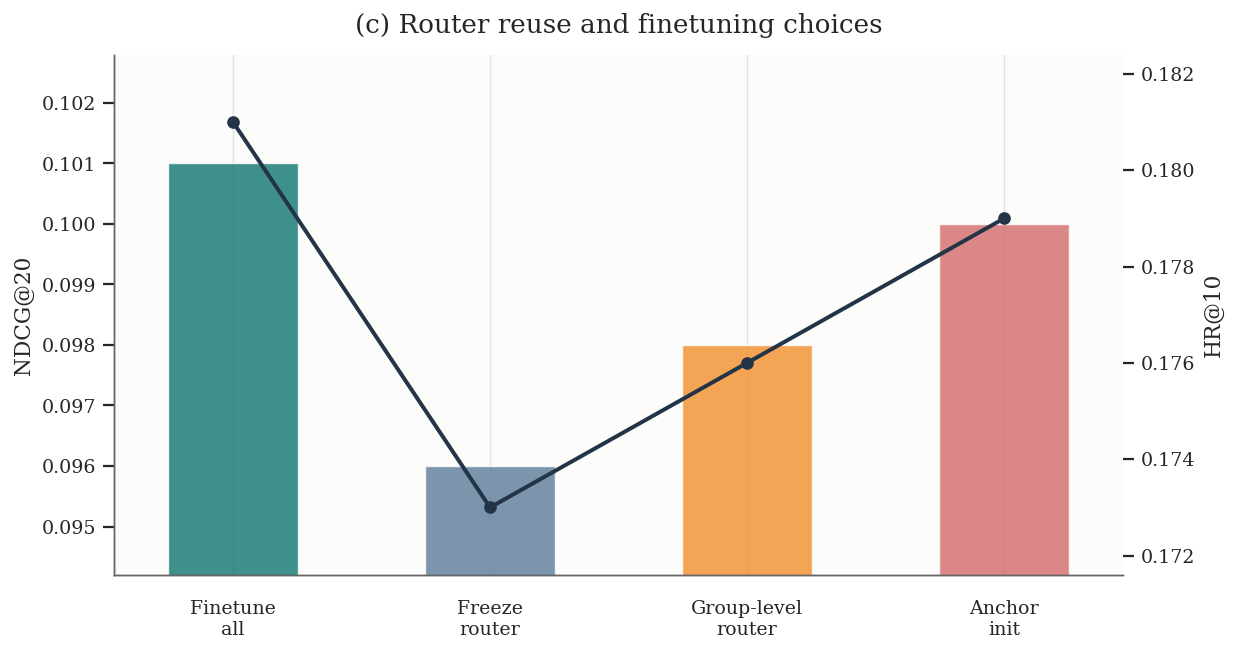

In [4]:
display(Markdown('### (b) Compact transfer-style support view'))
plot_df = variant_df.copy().sort_values('ndcg20', ascending=True)
fig, ax = plt.subplots(figsize=(9.8, 4.8), constrained_layout=True)
ax.barh(
    [transfer_label_map[value] for value in plot_df['variant']],
    plot_df['ndcg20'],
    color=['#D7E5E3', '#B9D4D0', '#8CB5AF', '#2A8C82'],
    edgecolor='white',
    linewidth=1.0,
)
for row in plot_df.itertuples():
    ax.annotate(
        f"NDCG@20 {row.ndcg20:.3f} | HR@10 {row.hr10:.3f}",
        (row.ndcg20, transfer_label_map[row.variant]),
        textcoords='offset points',
        xytext=(8, 0),
        va='center',
        fontsize=8.8,
        color='#3F3F46',
    )
ax.set_xlabel('NDCG@20')
ax.set_ylabel('Transfer-style reuse choice')
ax.set_title('(b) Full finetuning stays best, but some reuse choices degrade less gracefully than others')
ax.grid(axis='x', alpha=0.22)
plt.show()